# Concat Fusion & Trực quan hóa Khai phá (Grad-CAM)

- Ngắt bỏ Head của ResNet50 để lấy Vector 2048 chiều.
- Ghép nối tuyến tính (Concat) với Mảng Tabular.

In [1]:
import sys; sys.path.append('..')
import torch
import torch.nn as nn
from _shared_fusion_env import get_dataloaders, get_device
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# Thu viện Grad-CAM XAI
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = get_device()
train_loader, test_loader, weights, tab_dim = get_dataloaders(batch_size=32)
weights = weights.to(device)
print(f"Device: {device} | Tabular Dim: {tab_dim}")

Device: mps | Tabular Dim: 58


In [2]:
class ConcatFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=6):
        super().__init__()
        # ẢNH: Xóa bỏ lớp Linear cuối cùng để rút Vector 2048 chiều
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.img_net = nn.Sequential(*list(resnet.children())[:-1]) 
        
        # BẢNG: Ép kiểu Tabular về một Không gian 128 chiều
        self.tab_net = nn.Sequential(
            nn.Linear(tab_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3)
        )
        
        # NỐI CHẮP (Concat) 2048 + 128 = 2176 Chiều
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, img, tab):
        # Trích xuất Ảnh
        f_img = self.img_net(img)
        f_img = torch.flatten(f_img, 1) # (Batch, 2048)
        
        # Trích xuất Bảng
        f_tab = self.tab_net(tab) # (Batch, 128)
        
        # Ghép siêu Vector
        fused = torch.cat((f_img, f_tab), dim=1)
        return self.classifier(fused)

In [3]:
model = ConcatFusionModel(tab_dim).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

E1, E2 = 10, 60
# Giai đoạn 1: Khóa 80% xương sống ResNet
for param in model.img_net.parameters(): param.requires_grad = False
opt1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print("=== Phase 1: Feature Extractor Frozen (10 Epochs) ===")
for ep in range(E1):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt1.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls) 
        loss.backward()
        opt1.step()
        running_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {running_loss/len(train_loader):.4f}")

# Giai đoạn 2: Mở khóa hoàn toàn (Học vi phân )
for param in model.parameters(): param.requires_grad = True
opt2 = torch.optim.Adam(model.parameters(), lr=1e-5)

print("\n=== Phase 2: End-to-end Fine-tuning (40 Epochs) ===")
for ep in range(E2):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt2.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls)
        loss.backward()
        opt2.step()
        running_loss += loss.item()
    if (ep+1) % 5 == 0: print(f"Epoch {ep+E1+1} | Loss: {running_loss/len(train_loader):.4f}")

=== Phase 1: Feature Extractor Frozen (10 Epochs) ===


/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/122 [00:06<?, ?it/s]

Epoch 1 | Loss: 1.1353


  0%|          | 0/122 [00:00<?, ?it/s]

...

  0%|          | 0/122 [00:00<?, ?it/s]

  0%|          | 0/122 [00:00<?, ?it/s]

  0%|          | 0/122 [00:00<?, ?it/s]

  0%|          | 0/122 [00:00<?, ?it/s]

Epoch 70 | Loss: 0.0084


## Trực Quan Hóa (Bản Đồ Nhiệt Grad-CAM XAI)

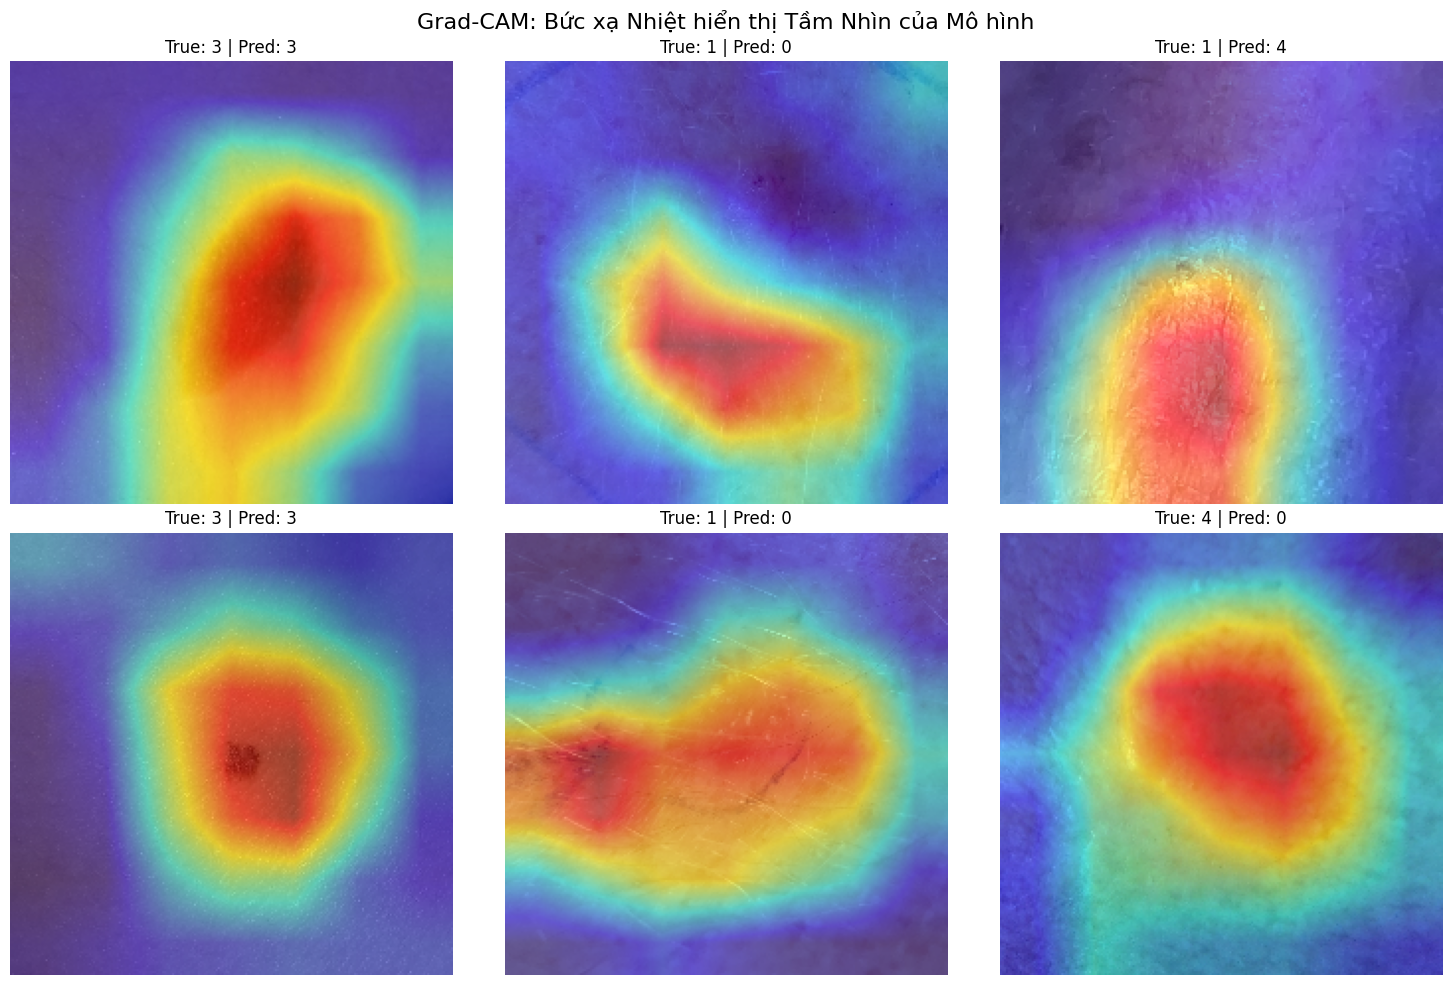

In [4]:
class ModelCAMWrapper(nn.Module):
    def __init__(self, model, fixed_tab):
        super().__init__()
        self.model = model
        self.fixed_tab = fixed_tab
    def forward(self, img):
        return self.model(img, self.fixed_tab)

model.eval()
imgs, tabs, lbls = next(iter(test_loader))
imgs, tabs = imgs.to(device), tabs.to(device)

# Cấu hình máy quét vào lớp Convolution sâu nhất của phần xương sống ResNet50
# Lưu ý ResNet50 trong nn.Sequential có cấu trúc layer4 ở vị trí [-2][-1]
target_layer = [model.img_net[-2][-1]]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    img_tensor = imgs[i].unsqueeze(0) # (1, 3, 224, 224)
    tab_tensor = tabs[i].unsqueeze(0)
    wrap_model = ModelCAMWrapper(model, tab_tensor)
    
    cam = GradCAM(model=wrap_model, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0, :]
    
    # De-normalize ảnh để vẽ
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    rgb_img = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    rgb_img = std * rgb_img + mean
    rgb_img = np.clip(rgb_img, 0, 1)
    
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    pred_val = torch.argmax(model(img_tensor, tab_tensor)).item()
    true_val = lbls[i].item()
    
    axes[i].imshow(visualization)
    axes[i].set_title(f"True: {true_val} | Pred: {pred_val}")
    axes[i].axis('off')

plt.suptitle("Grad-CAM: Bức xạ Nhiệt hiển thị Tầm Nhìn của Mô hình", fontsize=16)
plt.tight_layout()
plt.show()

  0%|          | 0/15 [00:00<?, ?it/s]


🏆 F1-Macro CONCAT FUSION: 0.7168


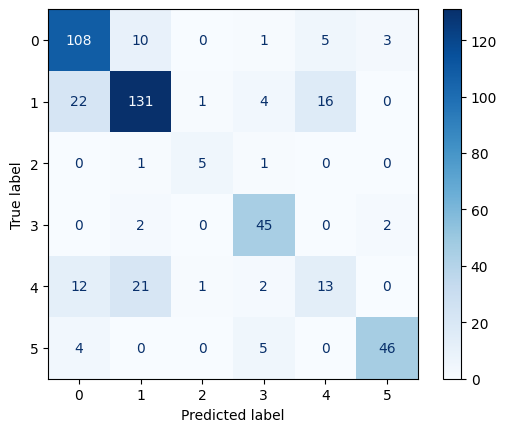

In [5]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for imgs, tabs, lbls in tqdm(test_loader):
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        preds.extend(y_hat.cpu().numpy())
        trues.extend(lbls.numpy())

f1 = f1_score(trues, preds, average='macro')
print(f"\n🏆 F1-Macro CONCAT FUSION: {f1:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix(trues, preds))
disp.plot(cmap='Blues')
plt.show()

## Lưu Mô hình (Model Checkpoint)
Bảo toàn Trọng số học được (Weights) để phục vụ cho Test độc lập hoặc Triển khai Web App/Mobile sau này mà không cần Train lại.

In [6]:
import os
os.makedirs('../../saved_models', exist_ok=True)
save_path = '../../saved_models/concat_fusion.pth'
torch.save(model.state_dict(), save_path)
print(f"✅ Đã lưu trọng số mô hình tại: {save_path}")

✅ Đã lưu trọng số mô hình tại: ../../saved_models/concat_fusion.pth
